# **1. Persiapan dan Import Library**
Kita mengimpor seluruh library yang dibutuhkan, termasuk TensorFlow/Keras untuk membangun arsitektur BiLSTM, dan callbacks untuk optimasi training.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import math
from datetime import timedelta

# Preprocessing & Evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning (Keras)
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Setting visualisasi
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# **2. Data Collection (Akuisisi Data)**
Kita mengambil data historis BRMS. Semakin banyak data untuk Deep Learning, semakin baik. Kita akan menarik data dari 5 tahun terakhir.

---

In [ ]:
# Mengambil data saham BRMS.JK (Bumi Resources Minerals Tbk)
ticker = 'BRMS.JK'
df = yf.download(ticker, start='2020-01-01', end='2026-03-15')

# Jika menggunakan yfinance versi terbaru, hilangkan multi-index columns jika ada
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Menampilkan informasi dasar
print("Shape Data:", df.shape)
display(df.tail())

/tmp/ipykernel_355/1753681038.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2026-03-15')
[*********************100%***********************]  1 of 1 completed

Shape Data: (1495, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,755.0,780.0,695.0,740.0,282191400
2026-03-10,855.0,875.0,775.0,790.0,364999000
2026-03-11,840.0,880.0,830.0,870.0,217966700
2026-03-12,815.0,845.0,800.0,830.0,171892300
2026-03-13,790.0,870.0,790.0,810.0,221945100


# **3. Exploratory Data Analysis (EDA)**
Tahap ini krusial untuk memahami karakteristik pergerakan, melihat distribusi, dan mendeteksi anomali.

---

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1495 entries, 2020-01-02 to 2026-03-13
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1495 non-null   float64
 1   High    1495 non-null   float64
 2   Low     1495 non-null   float64
 3   Open    1495 non-null   float64
 4   Volume  1495 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.1 KB
None

Missing Values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Price,Close,High,Low,Open,Volume
count,1495.000000,1495.000000,1495.000000,1495.000000,1.495000e+03
mean,240.849713,248.513016,234.331263,241.585671,4.731798e+08
std,255.208909,264.746909,246.700396,256.634844,5.913950e+08
min,43.610355,43.610355,43.610355,43.610355,2.290000e+02
25%,87.249344,90.033897,86.321159,88.177528,1.288888e+08
50%,162.000000,166.000000,159.000000,163.000000,2.953799e+08
75%,236.000000,242.000000,230.000000,236.000000,5.792976e+08
max,1310.000000,1385.000000,1260.000000,1335.000000,5.890471e+09


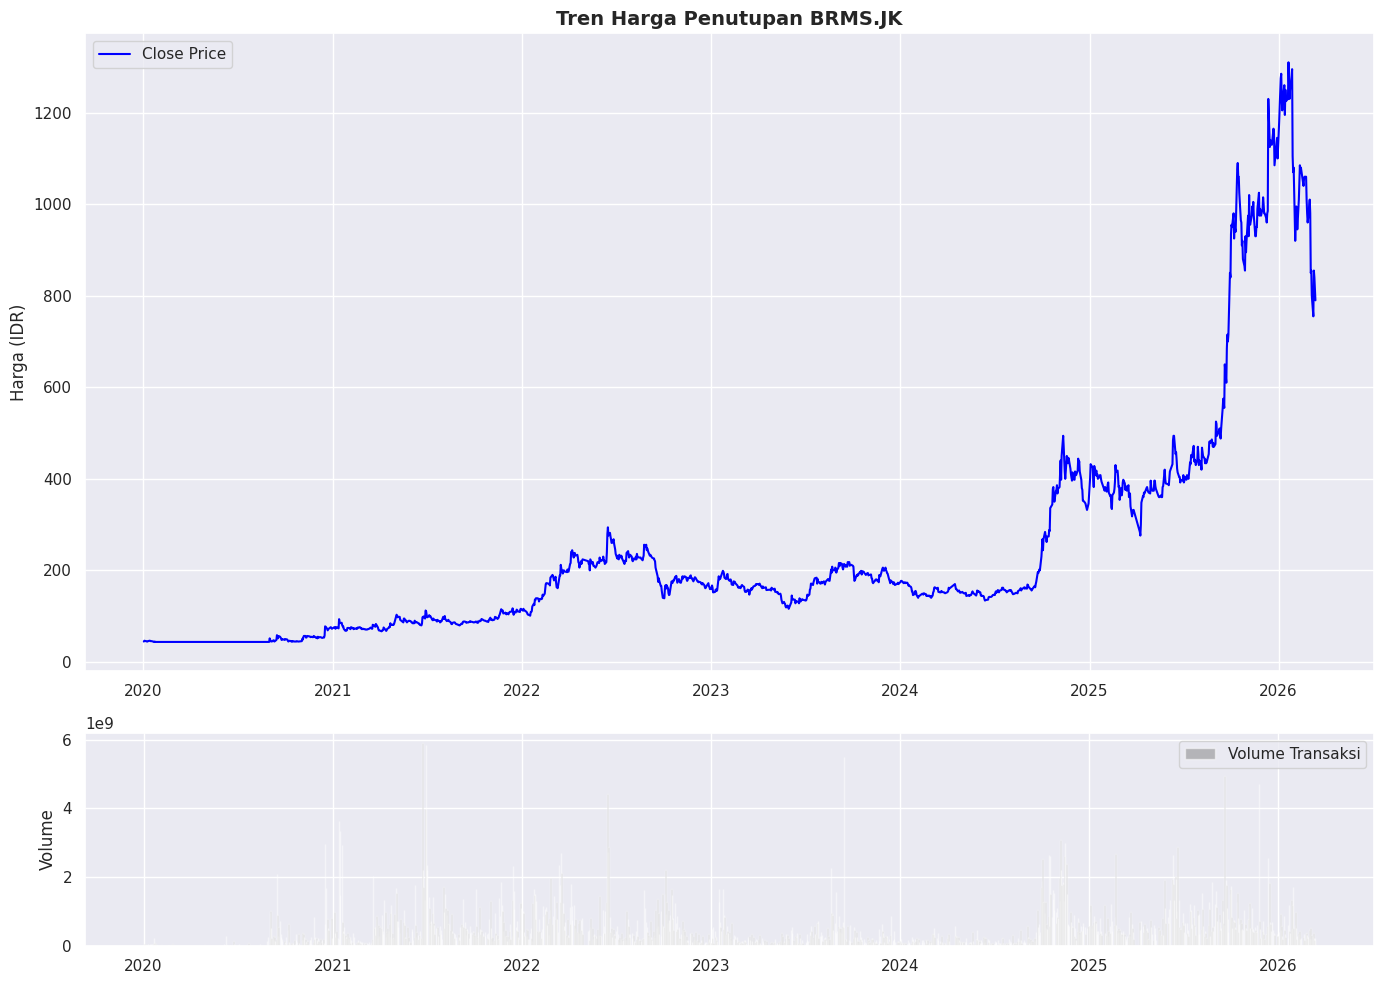

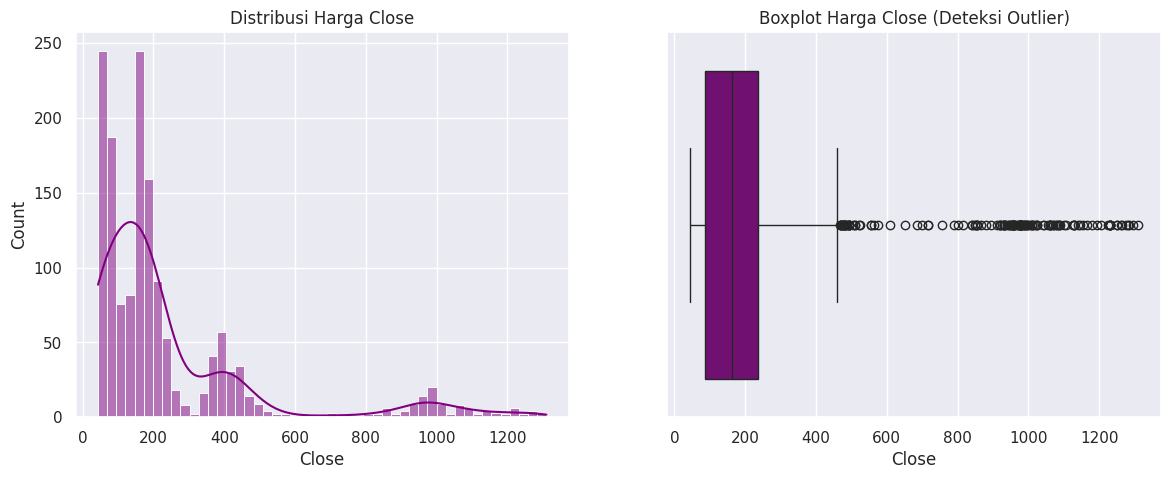

In [ ]:
# 1. Cek Missing Values & Tipe Data
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

# Drop missing values jika ada (misal hari libur nasional yang terekam kosong)
df.dropna(inplace=True)

# 2. Statistik Deskriptif
display(df.describe())

# 3. Visualisasi Tren Harga & Volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot Close Price
ax1.plot(df.index, df['Close'], color='blue', label='Close Price')
ax1.set_title(f'Tren Harga Penutupan {ticker}', fontsize=14, fontweight='bold')
ax1.set_ylabel('Harga (IDR)')
ax1.legend()

# Plot Volume
ax2.bar(df.index, df['Volume'], color='grey', alpha=0.5, label='Volume Transaksi')
ax2.set_ylabel('Volume')
ax2.legend()

plt.tight_layout()
plt.show()

# 4. Distribusi Harga (Histogram & Boxplot untuk cek outlier)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Close'], kde=True, color='purple')
plt.title('Distribusi Harga Close')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Close'], color='purple')
plt.title('Boxplot Harga Close (Deteksi Outlier)')
plt.show()

# **4. Data Preprocessing**
Neural Networks sangat sensitif terhadap skala data. Kita menggunakan MinMaxScaler untuk menekan nilai harga ke rentang $[0, 1]$.

---

In [ ]:
# Ekstraksi kolom Close untuk Univariate Time Series
data_close = df.filter(['Close']).values

# Normalisasi / Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_close)

print("Sample Data Scaled (5 pertama):")
print(scaled_data[:5])

Sample Data Scaled (5 pertama):
[[0.00068874]
 [0.00206621]
 [0.00137747]
 [0.00137747]
 [0.00068874]]


# **5. Windowing Time Series (4 Bulan)**
Kita mengubah deret waktu menjadi format Supervised Learning $(X, y)$. Window size 120 hari (4 bulan) berarti model akan melihat 120 hari ke belakang untuk menebak hari ke-121.

---

In [ ]:
window_size = 120

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape X ke format yang diterima LSTM: [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("Shape X (Input):", X.shape) # Output: (Jumlah_Sample, Window_size, 1)
print("Shape y (Target):", y.shape) # Output: (Jumlah_Sample,)

Shape X (Input): (1375, 120, 1)
Shape y (Target): (1375,)


# **6. Train-Test Split (Time-Series Aware)**
Pembagian data deret waktu tidak boleh diacak (randomize). Kita gunakan 85% data awal untuk Training dan 15% terakhir untuk Testing.

---

In [ ]:
# Proporsi split 85% Train, 15% Test
train_size = int(len(X) * 0.85)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Jumlah Data Training:", len(X_train))
print("Jumlah Data Testing:", len(X_test))

Jumlah Data Training: 1168
Jumlah Data Testing: 207


# **7. Model Building (BiLSTM)**
Kita membangun arsitektur dengan 2 lapis BiLSTM dan Dropout untuk mencegah overfitting (sebuah praktik standar karena pasar saham sangat noisy).

---

In [ ]:
# Membangun Arsitektur BiLSTM
model = Sequential()

# Layer BiLSTM Pertama
model.add(Bidirectional(LSTM(units=64, return_sequences=True), input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) # Mencegah overfitting

# Layer BiLSTM Kedua
model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.2))

# Layer Output
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1)) # Output 1 nilai (Harga prediksi hari esok)

# Kompilasi Model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 120, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,065 (297.13 KB)

 Trainable params: 76,065 (297.13 KB)

 Non-trainable params: 0 (0.00 B)

# **8. Model Training (dengan Early Stopping)**
Kita gunakan EarlyStopping agar proses training berhenti otomatis jika model tidak menunjukkan perbaikan (loss tidak turun), menghemat waktu dan mencegah overfitting.

---

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 229ms/step - loss: 0.0036 - val_loss: 0.0070
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - loss: 5.1264e-04 - val_loss: 0.0073
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step - loss: 3.6071e-04 - val_loss: 0.0039
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - loss: 2.6584e-04 - val_loss: 0.0079
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - loss: 2.8078e-04 - val_loss: 0.0041
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - loss: 2.4175e-04 - val_loss: 0.0031
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - loss: 2.6125e-04 - val_loss: 0.0071
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - loss: 2.0875e-04 - val_loss: 0.0050
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - loss: 2.2366e-04 - val_loss: 0.0057
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - loss: 2.1351e-04 - val_loss: 0.0043
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - loss: 2.0800e-04 - val_loss: 0.005

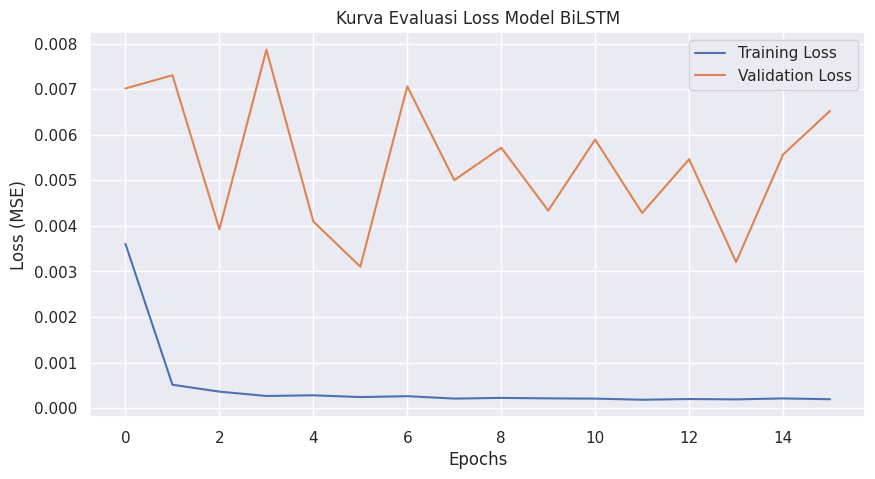

In [ ]:
# Setup Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_bilstm_model.keras', monitor='val_loss', save_best_only=True)

# Training Model
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100, # Kita set tinggi, EarlyStopping akan menghentikannya jika sudah optimal
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot Loss Kurva Training vs Validation
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kurva Evaluasi Loss Model BiLSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# **9. Model Evaluation**
Evaluasi performa model pada data Testing menggunakan metrik MAE, RMSE, dan rumus MAPE:

$$\text{MAPE} = \frac{1}{n} \sum \left| \frac{y - \hat{y}}{y} \right| \times 100$$


---

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step
--- Evaluasi Data Testing ---
MAE  : Rp 50.55
RMSE : Rp 70.57
MAPE : 6.41%


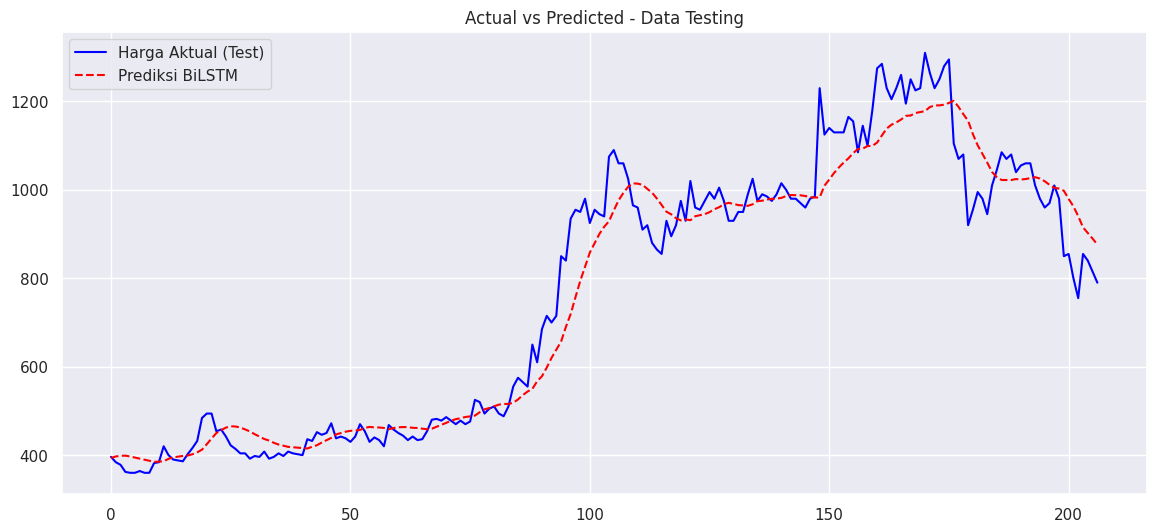

In [ ]:
# Prediksi data Test
predictions_scaled = model.predict(X_test)

# Kembalikan skala ke harga asli (Inverse Transform)
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Kalkulasi Metrik
mae = mean_absolute_error(y_test_actual, predictions)
rmse = math.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"--- Evaluasi Data Testing ---")
print(f"MAE  : Rp {mae:.2f}")
print(f"RMSE : Rp {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Plot Perbandingan Test Actual vs Predicted
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label='Harga Aktual (Test)', color='blue')
plt.plot(predictions, label='Prediksi BiLSTM', color='red', linestyle='dashed')
plt.title('Actual vs Predicted - Data Testing')
plt.legend()
plt.show()

# **10. Forecasting 60 Hari Ke Depan**
Ini adalah inti dari Quant Analysis. Kita mengambil 120 hari terakhir dari data saat ini, memprediksi hari ke-1 masa depan. Lalu hasil prediksi itu kita masukkan kembali (append) ke dalam window (menggeser window 1 hari ke depan) untuk memprediksi hari ke-2, dan seterusnya berulang 60 kali.

---

In [ ]:
# Ambil 120 data terakhir dari keseluruhan dataset asli
last_120_days = data_close[-window_size:]
last_120_days_scaled = scaler.transform(last_120_days)

X_forecast = []
X_forecast.append(last_120_days_scaled)
X_forecast = np.array(X_forecast)

forecast_60_days = []

# Loop Autoregresif untuk 60 hari
for _ in range(60):
    # Prediksi 1 hari ke depan dari window saat ini
    pred_scaled = model.predict(X_forecast, verbose=0)

    # Simpan hasil prediksi
    forecast_60_days.append(pred_scaled[0, 0])

    # Update window: buang data paling lama (index 0), masukkan prediksi terbaru di akhir
    pred_reshaped = np.reshape(pred_scaled, (1, 1, 1))
    X_forecast = np.append(X_forecast[:, 1:, :], pred_reshaped, axis=1)

# Inverse transform hasil prediksi ke harga asli Rupiah
forecast_60_days = scaler.inverse_transform(np.array(forecast_60_days).reshape(-1, 1))

# **11. Visualisasi Hasil Forecast & Tabel Prediksi**
Menyatukan data historis dengan hasil ramalan, dan membuat tabel yang rapi.

---

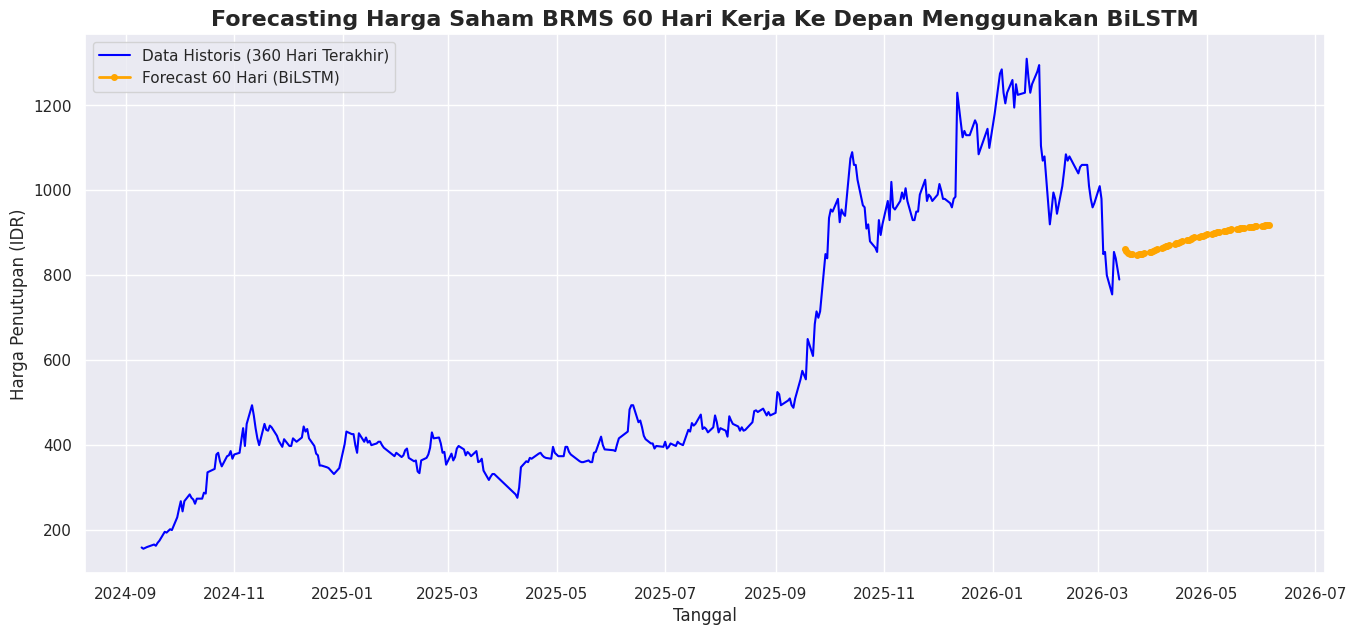


--- Tabel Prediksi 60 Hari Ke Depan ---


,Tanggal,Prediksi_Close_BRMS
0,2026-03-16,861.580017
1,2026-03-17,856.960022
2,2026-03-18,853.450012
3,2026-03-19,851.020020
4,2026-03-20,849.539978
5,2026-03-23,848.950012
6,2026-03-24,849.080017
7,2026-03-25,849.719971
8,2026-03-26,850.789978
9,2026-03-27,852.190002


In [ ]:
# Membuat tanggal masa depan (Hanya Hari Kerja/Business Days)
last_date = df.index[-1]
future_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=60)

# Membuat DataFrame untuk Tabel Hasil Prediksi
df_forecast = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi_Close_BRMS': forecast_60_days.flatten()
})

# Visualisasi Akhir
plt.figure(figsize=(16, 7))

# Plot 360 hari historis terakhir agar grafik terlihat proporsional
plt.plot(df.index[-360:], df['Close'][-360:], label='Data Historis (360 Hari Terakhir)', color='blue')

# Plot 60 Hari Forecast
plt.plot(df_forecast['Tanggal'], df_forecast['Prediksi_Close_BRMS'], label='Forecast 60 Hari (BiLSTM)', color='orange', linewidth=2, marker='o', markersize=4)

plt.title('Forecasting Harga Saham BRMS 60 Hari Kerja Ke Depan Menggunakan BiLSTM', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan (IDR)')
plt.legend()
plt.show()

print("\n--- Tabel Prediksi 60 Hari Ke Depan ---")
df_forecast['Tanggal'] = df_forecast['Tanggal'].dt.strftime('%Y-%m-%d') # Format tanggal
df_forecast['Prediksi_Close_BRMS'] = df_forecast['Prediksi_Close_BRMS'].round(2)
display(df_forecast)

# Opsional: Menyimpan model final
# model.save('final_riksa_bilstm.keras')